# 02 · EDA: Global Video Game Sales
**Group 10: Mobile App Ecosystem Dynamics and Direct Bank Marketing Pipelines**

Dataset: https://www.kaggle.com/datasets/gregorut/videogamesales (games with > 100K copies sold, sales in millions)

Goal: understand the revenue lifecycle of the games industry: how the market grew and shrank,
which genres, platforms and publishers dominate, and how tastes differ by region.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.viz import *

set_style()
df_raw = pd.read_csv(RAW / "video_game_sales" / "vgsales.csv")
print(df_raw.shape)
df_raw.head()

(16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 1. Data quality audit

In [2]:
print("Duplicate rows:", df_raw.duplicated().sum())
print("Duplicate (Name, Platform, Year):", df_raw.duplicated(["Name", "Platform", "Year"]).sum())
pd.DataFrame({"dtype": df_raw.dtypes.astype(str), "missing": df_raw.isna().sum(),
              "unique": df_raw.nunique()})

Duplicate rows: 0
Duplicate (Name, Platform, Year): 2


,dtype,missing,unique
Rank,int64,0,16598
Name,str,0,11493
Platform,str,0,31
Year,float64,271,39
Genre,str,0,12
Publisher,str,58,578
NA_Sales,float64,0,409
EU_Sales,float64,0,305
JP_Sales,float64,0,244
Other_Sales,float64,0,157


In [3]:
df_raw["Year"].value_counts().sort_index().tail(8)

Year
2011.0    1139
2012.0     657
2013.0     546
2014.0     582
2015.0     614
2016.0     344
2017.0       3
2020.0       1
Name: count, dtype: int64

In [4]:
# Do regional columns add up to Global_Sales? (rounding differences expected)
diff = (df_raw[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum(axis=1) - df_raw["Global_Sales"]).abs()
print(f"Max |sum(regions) − global| = {diff.max():.2f}M; rows off by > 0.02M: {(diff > 0.02).sum()}")

Max |sum(regions) − global| = 0.02M; rows off by > 0.02M: 7


## 2. Cleaning
- Drop 271 games without a release `Year` (1.6 %); they cannot be placed on the timeline.
- Keep years ≤ 2016: the scrape happened in late 2016, so 2017/2020 have only 4 games (incomplete, would fake a crash).
- `Publisher` missing for 58 games → "Unknown".
- Sales are kept as-is (they are real extreme values, not errors), but plotted on log scales.

In [5]:
df = df_raw.dropna(subset=["Year"]).copy()
df["Year"] = df["Year"].astype(int)
df = df[df["Year"] <= 2016]
df["Publisher"] = df["Publisher"].fillna("Unknown")
REGIONS = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
REGION_NAMES = {"NA_Sales": "North America", "EU_Sales": "Europe", "JP_Sales": "Japan", "Other_Sales": "Other"}
print(f"Rows: {len(df_raw):,} → {len(df):,}")
df.to_csv(PROCESSED / "vgsales_clean.csv", index=False)
df[REGIONS + ["Global_Sales"]].describe().T.round(3)

Rows: 16,598 → 16,323


,count,mean,std,min,25%,50%,75%,max
NA_Sales,16323.0,0.265,0.822,0.00,0.00,0.08,0.24,41.49
EU_Sales,16323.0,0.148,0.509,0.00,0.00,0.02,0.11,29.02
JP_Sales,16323.0,0.079,0.312,0.00,0.00,0.00,0.04,10.22
Other_Sales,16323.0,0.048,0.190,0.00,0.00,0.01,0.04,10.57
Global_Sales,16323.0,0.540,1.566,0.01,0.06,0.17,0.48,82.74


## 3. Distribution of sales

findfont: Failed to find font weight semibold for Helvetica Neue, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


Skewness: 17.3;  top 1% of games = 21.1% of all sales


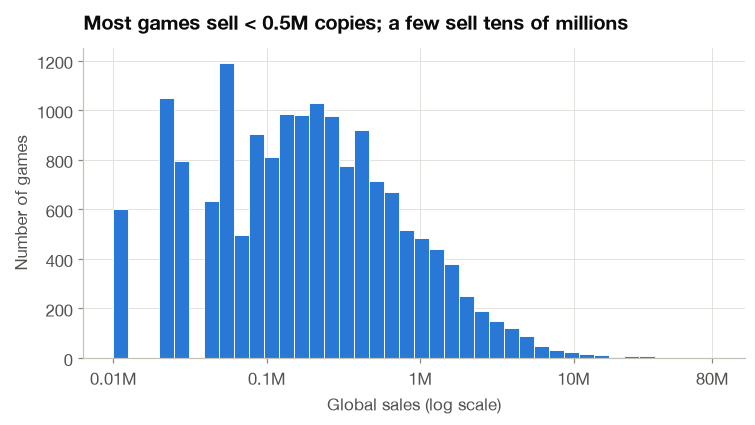

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(df["Global_Sales"]), bins=40, color=BLUE, edgecolor=SURFACE, linewidth=0.6)
ticks = [0.01, 0.1, 1, 10, 80]
ax.set_xticks(np.log10(ticks), [f"{t:g}M" for t in ticks])
ax.set(title="Most games sell < 0.5M copies; a few sell tens of millions",
       xlabel="Global sales (log scale)", ylabel="Number of games")
save(fig, "vg_sales_distribution")
top1 = df.nlargest(int(len(df) * 0.01), "Global_Sales")["Global_Sales"].sum() / df["Global_Sales"].sum()
print(f"Skewness: {df['Global_Sales'].skew():.1f};  top 1% of games = {top1:.1%} of all sales")

## 4. The industry lifecycle over time

,games,sales
Year,,
2005,941,459.94
2006,1008,521.04
2007,1202,611.13
2008,1428,678.90
2009,1431,667.30
2010,1259,600.45
2011,1139,515.99
2012,657,363.54
2013,546,368.11


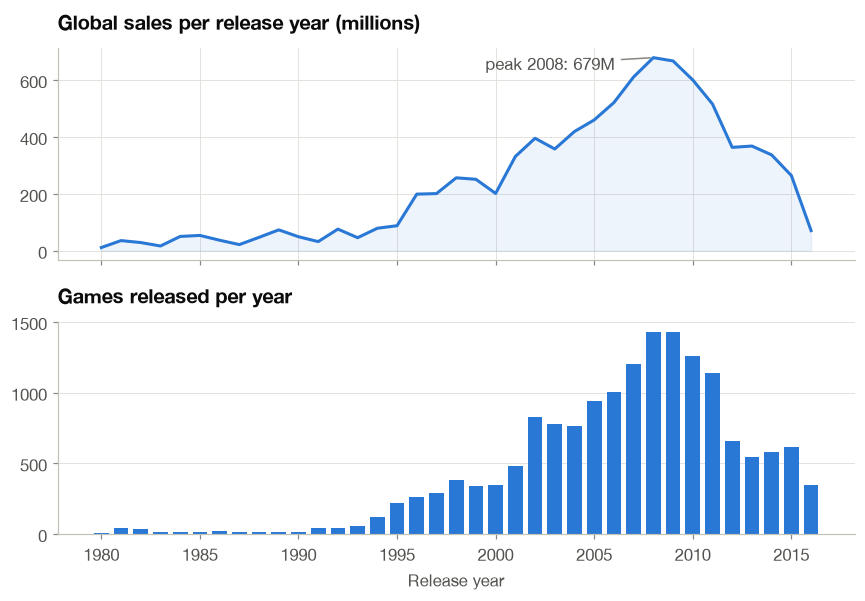

In [7]:
yearly = df.groupby("Year").agg(games=("Name", "size"), sales=("Global_Sales", "sum"))
fig, axes = plt.subplots(2, 1, figsize=(8, 5.6), sharex=True)
axes[0].plot(yearly.index, yearly["sales"], color=SERIES[0])
axes[0].fill_between(yearly.index, yearly["sales"], color=SERIES[0], alpha=0.08)
axes[0].set(title="Global sales per release year (millions)")
pk = yearly["sales"].idxmax()
axes[0].annotate(f"peak {pk}: {yearly.loc[pk, 'sales']:.0f}M", (pk, yearly.loc[pk, "sales"]),
                 xytext=(-110, -8), textcoords="offset points", color=INK_2,
                 arrowprops=dict(arrowstyle="-", color=MUTED))
axes[1].bar(yearly.index, yearly["games"], color=SERIES[0], width=0.75)
axes[1].set(title="Games released per year", xlabel="Release year")
axes[1].grid(axis="x", visible=False)
save(fig, "vg_lifecycle")
yearly.tail(12)

## 5. Genres, platforms and publishers

,games,sales,avg_sales
Genre,,,
Platform,876,829.15,0.947
Shooter,1282,1026.20,0.800
Role-Playing,1469,923.80,0.629
Racing,1226,726.77,0.593
Sports,2304,1309.24,0.568
Fighting,836,444.05,0.531
Action,3252,1722.87,0.530
Misc,1710,797.62,0.466
Simulation,850,389.87,0.459


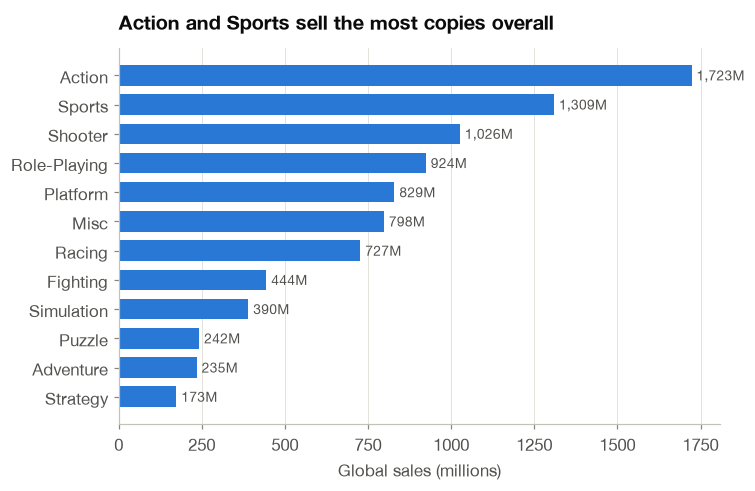

In [8]:
genre = df.groupby("Genre").agg(games=("Name", "size"), sales=("Global_Sales", "sum"),
                                avg_sales=("Global_Sales", "mean")).sort_values("sales")
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(genre.index, genre["sales"], color=BLUE, height=0.7)
for y, v in enumerate(genre["sales"]):
    ax.text(v + 15, y, f"{v:,.0f}M", va="center", fontsize=9, color=INK_2)
ax.set(title="Action and Sports sell the most copies overall", xlabel="Global sales (millions)")
ax.grid(axis="y", visible=False)
save(fig, "vg_sales_by_genre")
genre.sort_values("avg_sales", ascending=False).round(3)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Shooter,56.1,30.3,3.7,9.9
Racing,49.1,32.5,7.8,10.6
Action,50.1,30.0,9.2,10.7
Sports,51.2,28.4,10.3,10.1
Misc,50.5,26.8,13.4,9.3
Platform,53.8,24.2,15.8,6.2
Simulation,46.6,29.1,16.3,8.0
Fighting,49.7,22.5,19.6,8.1
Adventure,43.5,27.2,22.2,7.1


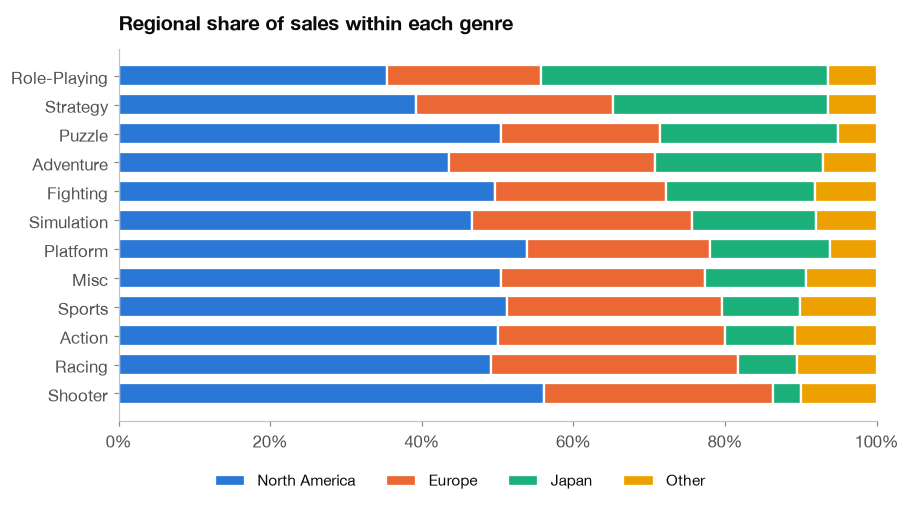

In [9]:
reg = df.groupby("Genre")[REGIONS].sum()
reg_share = reg.div(reg.sum(axis=1), axis=0).sort_values("JP_Sales")
fig, ax = plt.subplots(figsize=(8.4, 4.8))
left = np.zeros(len(reg_share))
for i, r in enumerate(REGIONS):
    ax.barh(reg_share.index, reg_share[r], left=left, color=SERIES[i], height=0.72,
            edgecolor=SURFACE, linewidth=1.5, label=REGION_NAMES[r])
    left += reg_share[r].values
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set(xlim=(0, 1), title="Regional share of sales within each genre")
ax.legend(ncol=4, loc="lower center", bbox_to_anchor=(0.45, -0.22))
ax.grid(False)
save(fig, "vg_region_share_by_genre")
(reg_share * 100).round(1)

In [10]:
region_top = {REGION_NAMES[r]: reg[r].sort_values(ascending=False).index[:3].tolist() for r in REGIONS}
region_top

{'North America': ['Action', 'Sports', 'Shooter'],
 'Europe': ['Action', 'Sports', 'Shooter'],
 'Japan': ['Role-Playing', 'Action', 'Sports'],
 'Other': ['Action', 'Sports', 'Shooter']}

Publishers: 576; top-5 share of sales = 53.1%


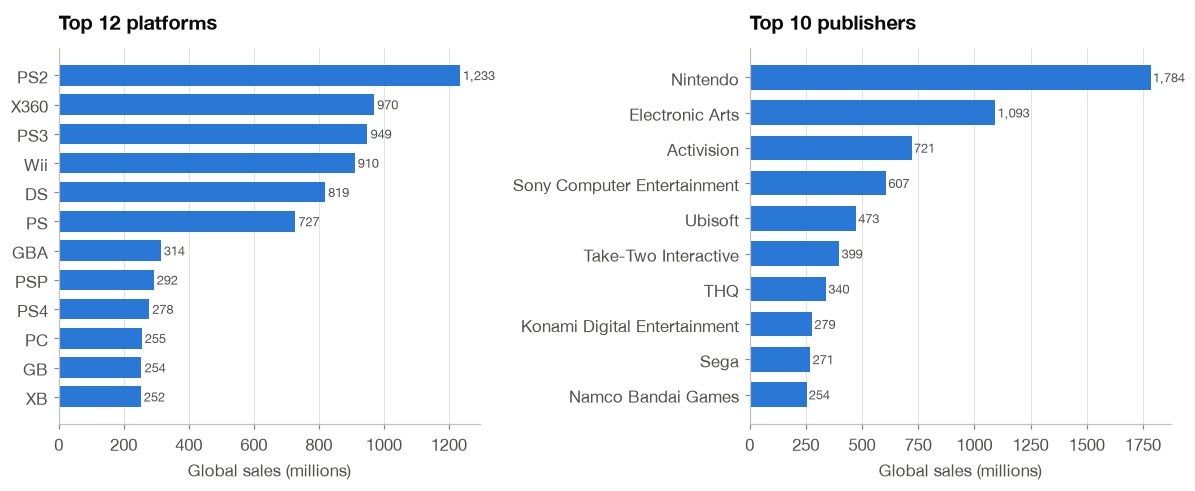

In [11]:
plat = df.groupby("Platform")["Global_Sales"].sum().nlargest(12).sort_values()
pub = df.groupby("Publisher")["Global_Sales"].sum().nlargest(10).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, s, t in [(axes[0], plat, "Top 12 platforms"), (axes[1], pub, "Top 10 publishers")]:
    ax.barh(s.index, s.values, color=BLUE, height=0.7)
    for y, v in enumerate(s.values):
        ax.text(v + 10, y, f"{v:,.0f}", va="center", fontsize=8.5, color=INK_2)
    ax.set(title=t, xlabel="Global sales (millions)")
    ax.grid(axis="y", visible=False)
save(fig, "vg_platforms_publishers")
top5_pub_share = df.groupby("Publisher")["Global_Sales"].sum().nlargest(5).sum() / df["Global_Sales"].sum()
print(f"Publishers: {df['Publisher'].nunique()}; top-5 share of sales = {top5_pub_share:.1%}")

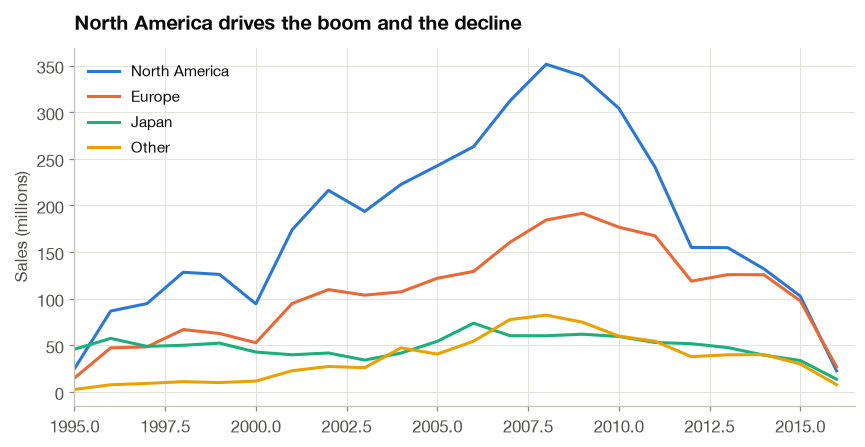

In [12]:
region_year = df.groupby("Year")[REGIONS].sum().loc[1995:]
fig, ax = plt.subplots(figsize=(8, 4.2))
for i, r in enumerate(REGIONS):
    ax.plot(region_year.index, region_year[r], color=SERIES[i], label=REGION_NAMES[r])
ax.set(title="North America drives the boom and the decline", ylabel="Sales (millions)", xlim=(1995, 2016.5))
ax.legend(loc="upper left")
save(fig, "vg_region_trend")

,NA,EU,JP,Other,Global
NA,1.00,0.77,0.45,0.63,0.94
EU,0.77,1.00,0.44,0.73,0.90
JP,0.45,0.44,1.00,0.29,0.61
Other,0.63,0.73,0.29,1.00,0.75
Global,0.94,0.90,0.61,0.75,1.00


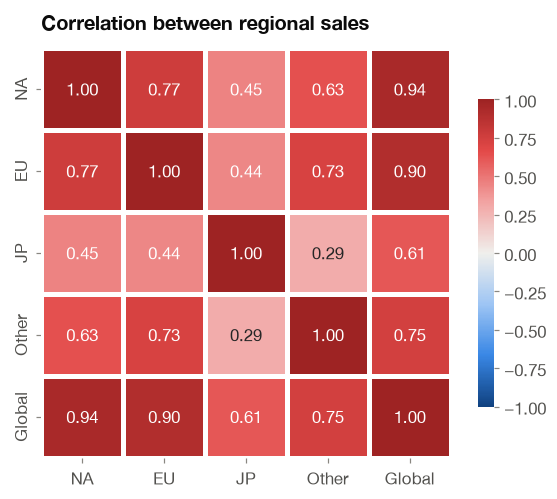

In [13]:
corr = df[REGIONS + ["Global_Sales"]].rename(columns=lambda c: c.replace("_Sales", "")).corr()
fig, ax = plt.subplots(figsize=(5.6, 4.6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING, vmin=-1, vmax=1, square=True,
            linewidths=2, linecolor=SURFACE, cbar_kws={"shrink": 0.75}, ax=ax)
ax.set(title="Correlation between regional sales")
ax.grid(False)
save(fig, "vg_correlation")
corr.round(2)

## 6. Key insights

In [14]:
insights = {
    "rows_raw": len(df_raw), "rows_clean": len(df),
    "year_min": int(df["Year"].min()), "year_max": int(df["Year"].max()),
    "median_sales": df["Global_Sales"].median(), "max_game": df.loc[df["Global_Sales"].idxmax(), "Name"],
    "max_sales": df["Global_Sales"].max(), "skew": df["Global_Sales"].skew(), "top1pct_share": top1 * 100,
    "peak_year": int(pk), "peak_sales": yearly.loc[pk, "sales"], "peak_games_year": int(yearly["games"].idxmax()),
    "top_genre": genre["sales"].idxmax(), "top_genre_sales": genre["sales"].max(),
    "top_avg_genre": genre["avg_sales"].idxmax(), "top_avg_value": genre["avg_sales"].max(),
    "region_share": (df[REGIONS].sum() / df["Global_Sales"].sum() * 100).round(1).to_dict(),
    "jp_top_genre": reg["JP_Sales"].idxmax(), "jp_rpg_share": reg_share.loc["Role-Playing", "JP_Sales"] * 100,
    "na_shooter_share": reg_share.loc["Shooter", "NA_Sales"] * 100,
    "top_platform": plat.index[-1], "top_platform_sales": plat.iloc[-1],
    "top_publisher": pub.index[-1], "top_publisher_sales": pub.iloc[-1],
    "n_publishers": df["Publisher"].nunique(), "top5_pub_share": top5_pub_share * 100,
    "corr_na_global": corr.loc["NA", "Global"], "corr_jp_global": corr.loc["JP", "Global"],
    "region_top_genres": region_top,
}
save_json(insights, "vgsales_insights")
pd.Series(insights)

rows_raw                                                           16598
rows_clean                                                         16323
year_min                                                            1980
year_max                                                            2016
median_sales                                                        0.17
max_game                                                      Wii Sports
max_sales                                                          82.74
skew                                                           17.319069
top1pct_share                                                  21.138274
peak_year                                                           2008
peak_sales                                                         678.9
peak_games_year                                                     2009
top_genre                                                         Action
top_genre_sales                                    

**Insights**
1. **Hit-driven market**: median game sells 0.17M, skewness ≈ 17; the top 1 % of games earn ~21 % of all sales (Wii Sports alone: 82.7M).
2. **Industry lifecycle**: steady growth from the mid-1990s to a **peak in 2008 (679M)**, then a sharp decline. Part of the post-2012 fall is real (shift to mobile/digital), part is data-related (only boxed retail, and 2016 was scraped mid-year).
3. **Action and Sports** sell the most in total, but **Platform** games sell the most *per title* (~0.95M avg) → fewer, bigger hits.
4. **North America = 49 % of all sales**, Europe 27 %, Japan 15 %. NA sales correlate 0.94 with global sales; Japan only 0.61 → Japan is a distinct market.
5. **Regional taste differs**: Role-Playing is Japan's #1 genre (38 % of RPG sales come from Japan), while Shooters are 56 % North American.
6. **Concentration**: 576 publishers, but the top 5 (Nintendo, EA, Activision, Sony, Ubisoft) hold 53 % of sales; PS2 is the best-selling platform.